In [41]:
import sys
sys.path.insert(0, '..')

In [42]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [43]:
wid = 80
oversample = 4

nwavels = 20
npoly=nwavels

n_zernikes = 10#30#12

optics = NICMOSCoronagraph(512, wid, oversample, n_zernikes = n_zernikes, n_modes=5)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.eye(nwavels)



In [44]:
key_name = "n8zu81f4q"
filtname="F110W"
wavels, bandpass = calc_throughput(filtname, nwavels=nwavels)

In [45]:
exposures = [
    BlankExposure(key_name, filtname, SinglePointFit(spectrum_basis, filtname, precombined=False, wavels=wavels))
] 


/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_99427/2224783406.py:2: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  BlankExposure(key_name, filtname, SinglePointFit(spectrum_basis, filtname, precombined=False, wavels=wavels))


In [46]:
base_params = np.load("params.npy", allow_pickle=True)[()]

In [47]:
params = base_params | {"spectrum": {f"{key_name}_{filtname}": np.ones(nwavels)}}

injected_model = set_array(NICMOSModel(exposures, params, optics, detector))

injected_params = ModelParams(params)

In [48]:
exposures = [
    #InjectedExposure("test", 'F110W', SinglePointSpectrumFit(nwavels), injected_model, 287*1e-3, 10)
    InjectedExposure(key_name, filtname, SinglePointFit(spectrum_basis, filtname), injected_model, 10000, 1, read_noise=0.)
]

/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_99427/1484213243.py:3: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  InjectedExposure(key_name, filtname, SinglePointFit(spectrum_basis, filtname), injected_model, 10000, 1, read_noise=0.)


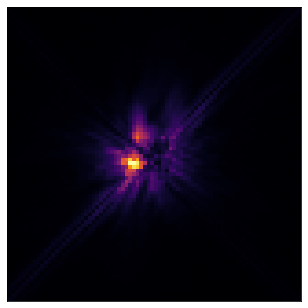

In [49]:
plt.imshow(exposures[0].data**0.125)
plt.xticks([])
plt.yticks([])
plt.tight_layout()

In [50]:
model = set_array(NICMOSModel(exposures, injected_params.params, optics, detector))

old_params = params
params = injected_params#ModelParams(injected_params)

In [51]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))

spec_params = ModelParams({"spectrum": injected_params.get("spectrum")})

f = lambda params: loss_fn(ModelParams(injected_params.params | params.params), exposures, params.inject((model)))
F, unflatten = zdx.batching.hessian(f, spec_params, nbatches=20*len(exposures))

# S_inv = 1.0 / np.sqrt(np.diag(F))
# F = S_inv[:, None] * F * S_inv[None, :]

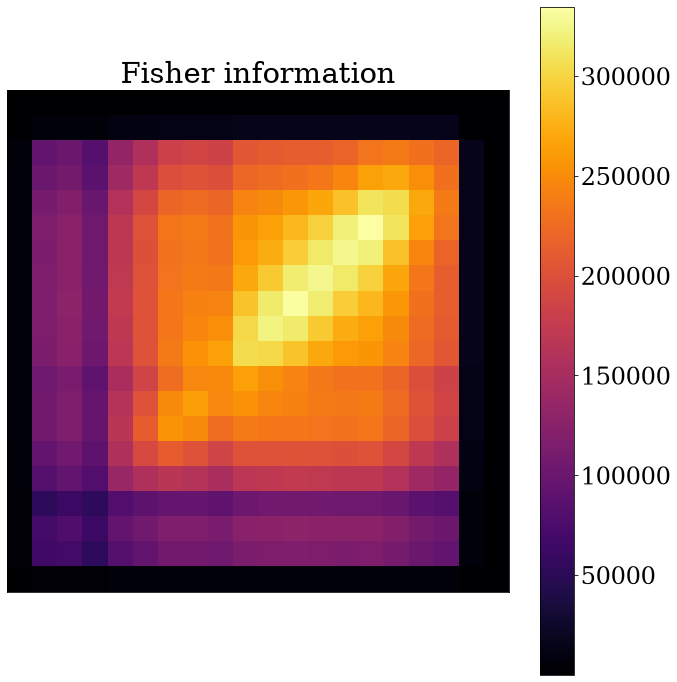

In [52]:
plt.figure(figsize=(10,10))
plt.imshow(F, interpolation='none')
plt.title("Fisher information")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.tight_layout()

Text(0, 0.5, 'Eigenvalue')

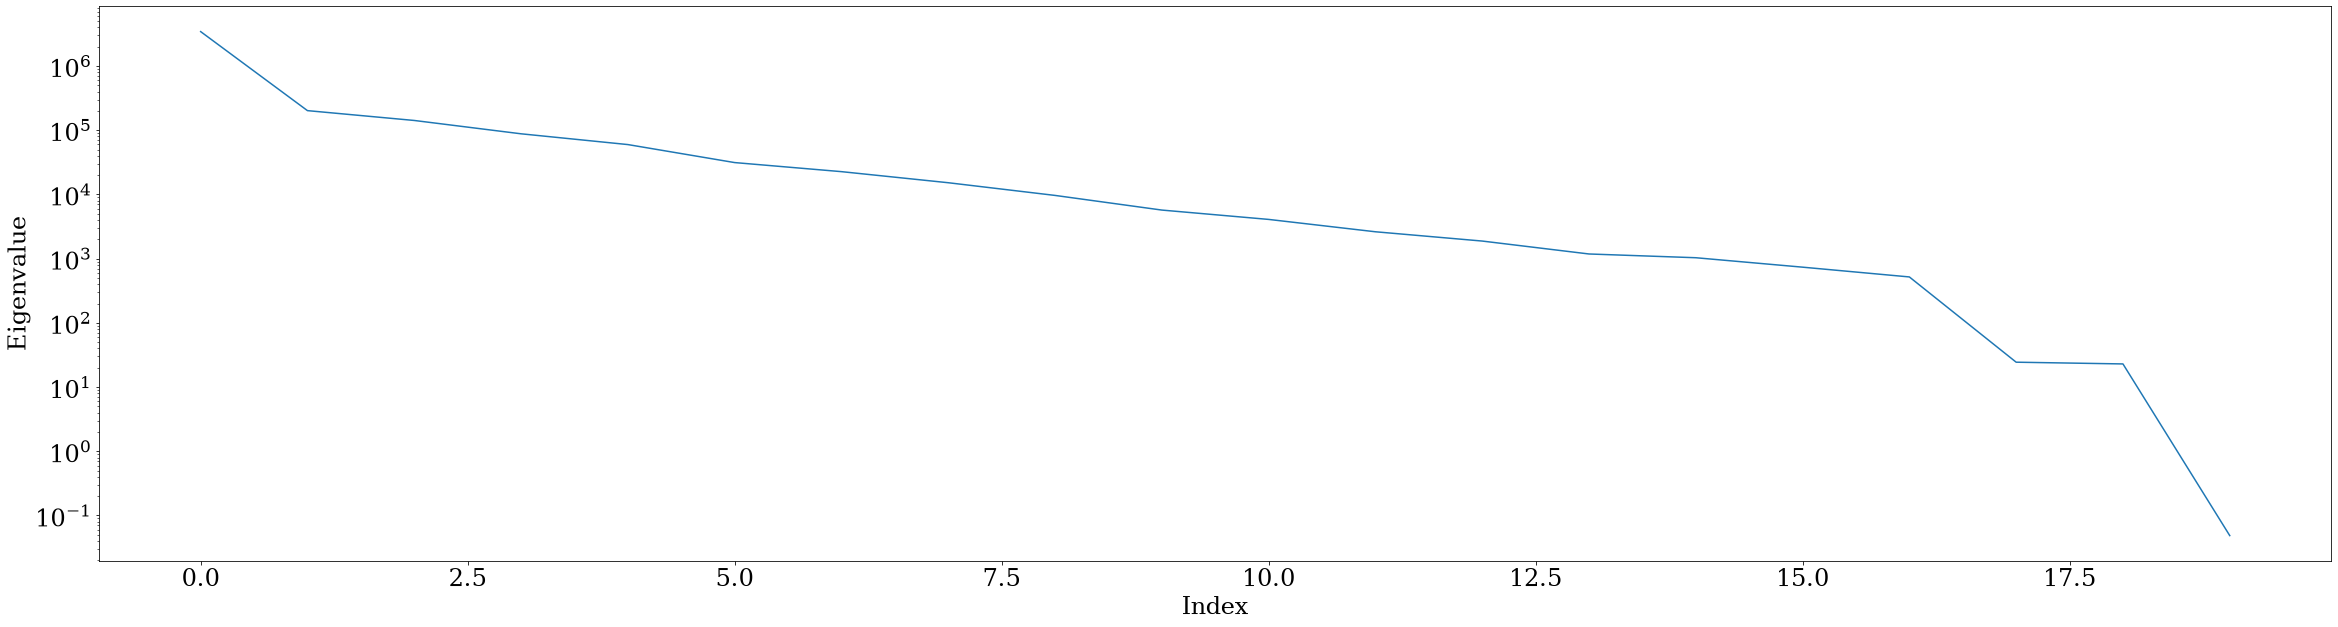

In [53]:
plt.figure(figsize=(40,10))
plt.semilogy(np.real(np.linalg.eig(F)[0].sort()[::-1])[:50])
plt.xlabel("Index")
plt.ylabel("Eigenvalue")

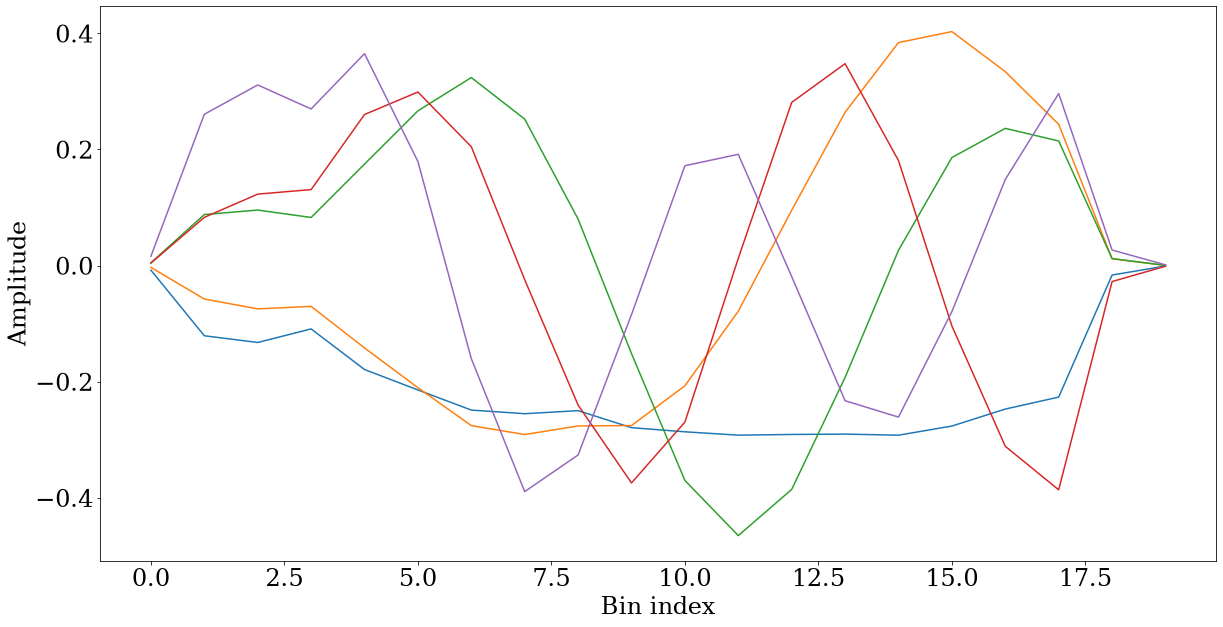

In [54]:
vals, vects = np.linalg.eig(F)

order = np.argsort(vals)[::-1]

plt.figure(figsize=(20,10))
plt.xlabel("Bin index")
plt.ylabel("Amplitude")

for i in range(5):
    plt.plot(np.real(vects[:,order[i]]))

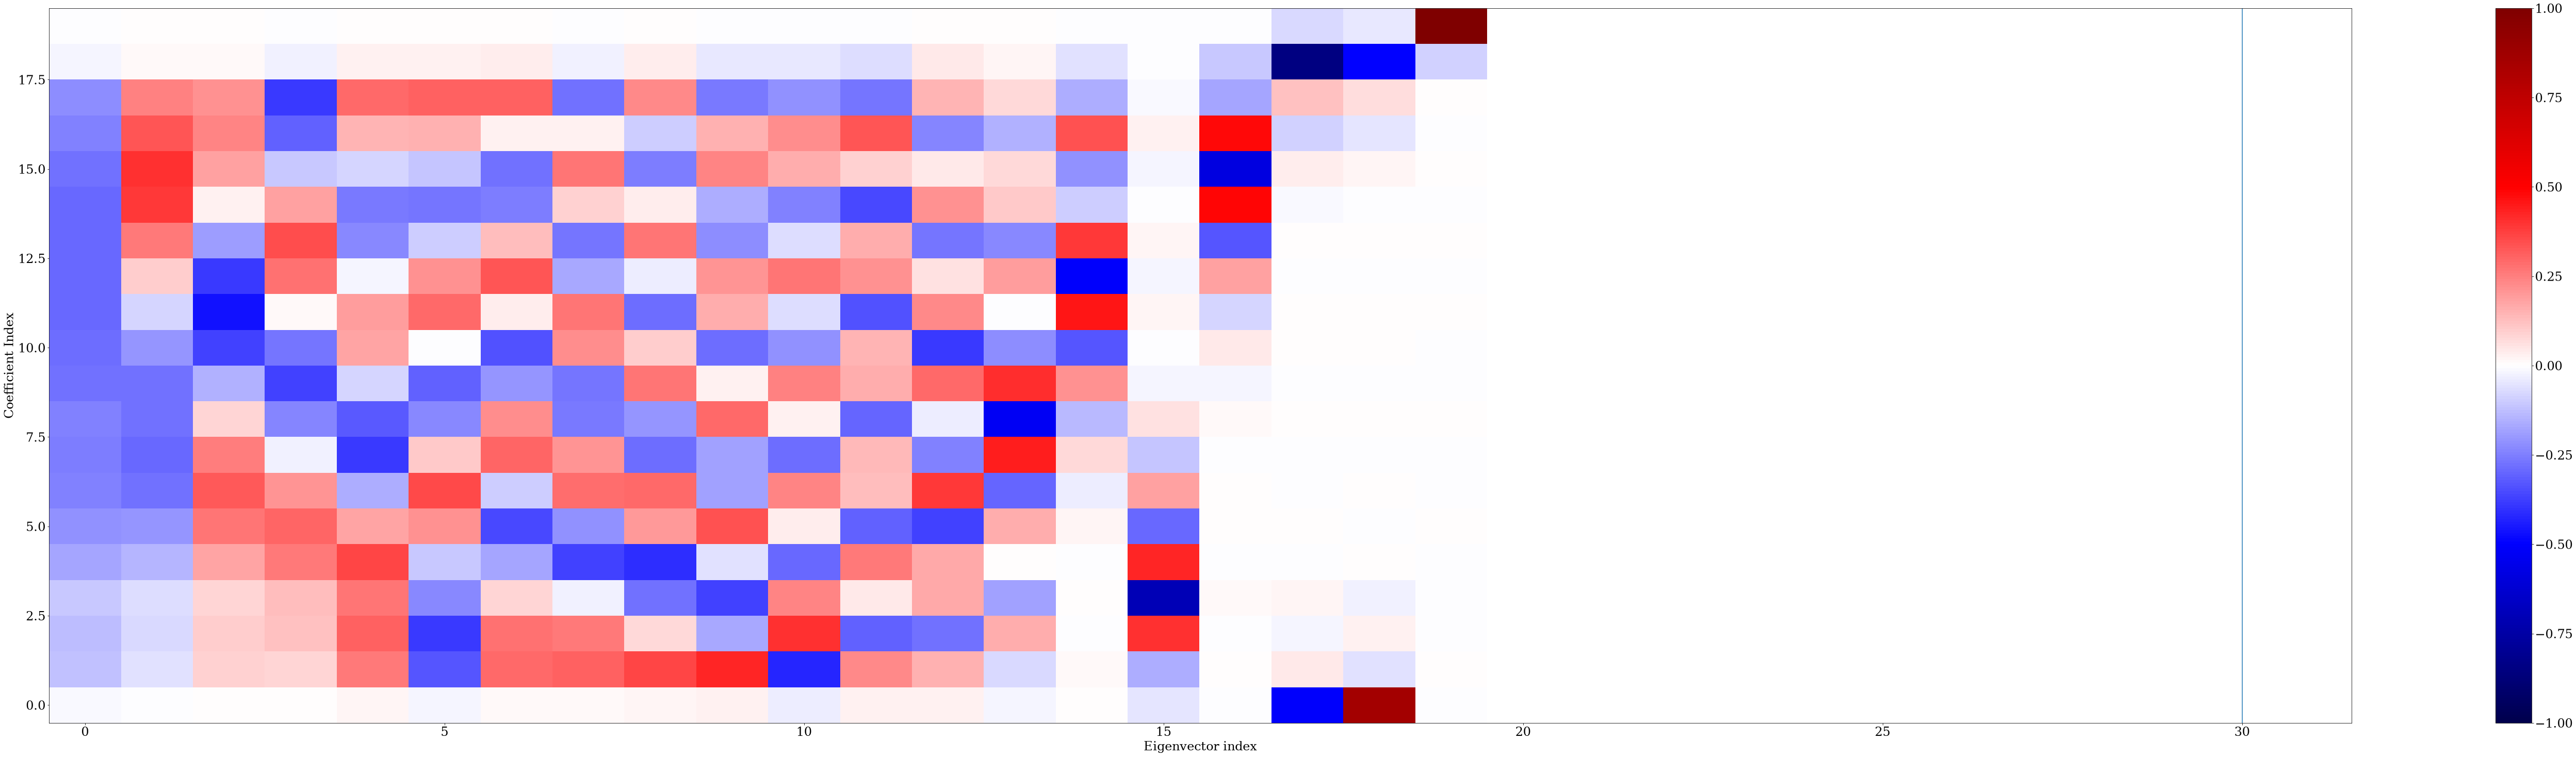

In [55]:
plt.figure(figsize=(20*5,5*5))
plt.imshow(np.real(vects[:,order[:]]), cmap='seismic', vmax=1, vmin=-1, interpolation='none', aspect='auto')
plt.xlabel("Eigenvector index")
plt.ylabel("Coefficient Index")
plt.colorbar()
plt.axvline(30)

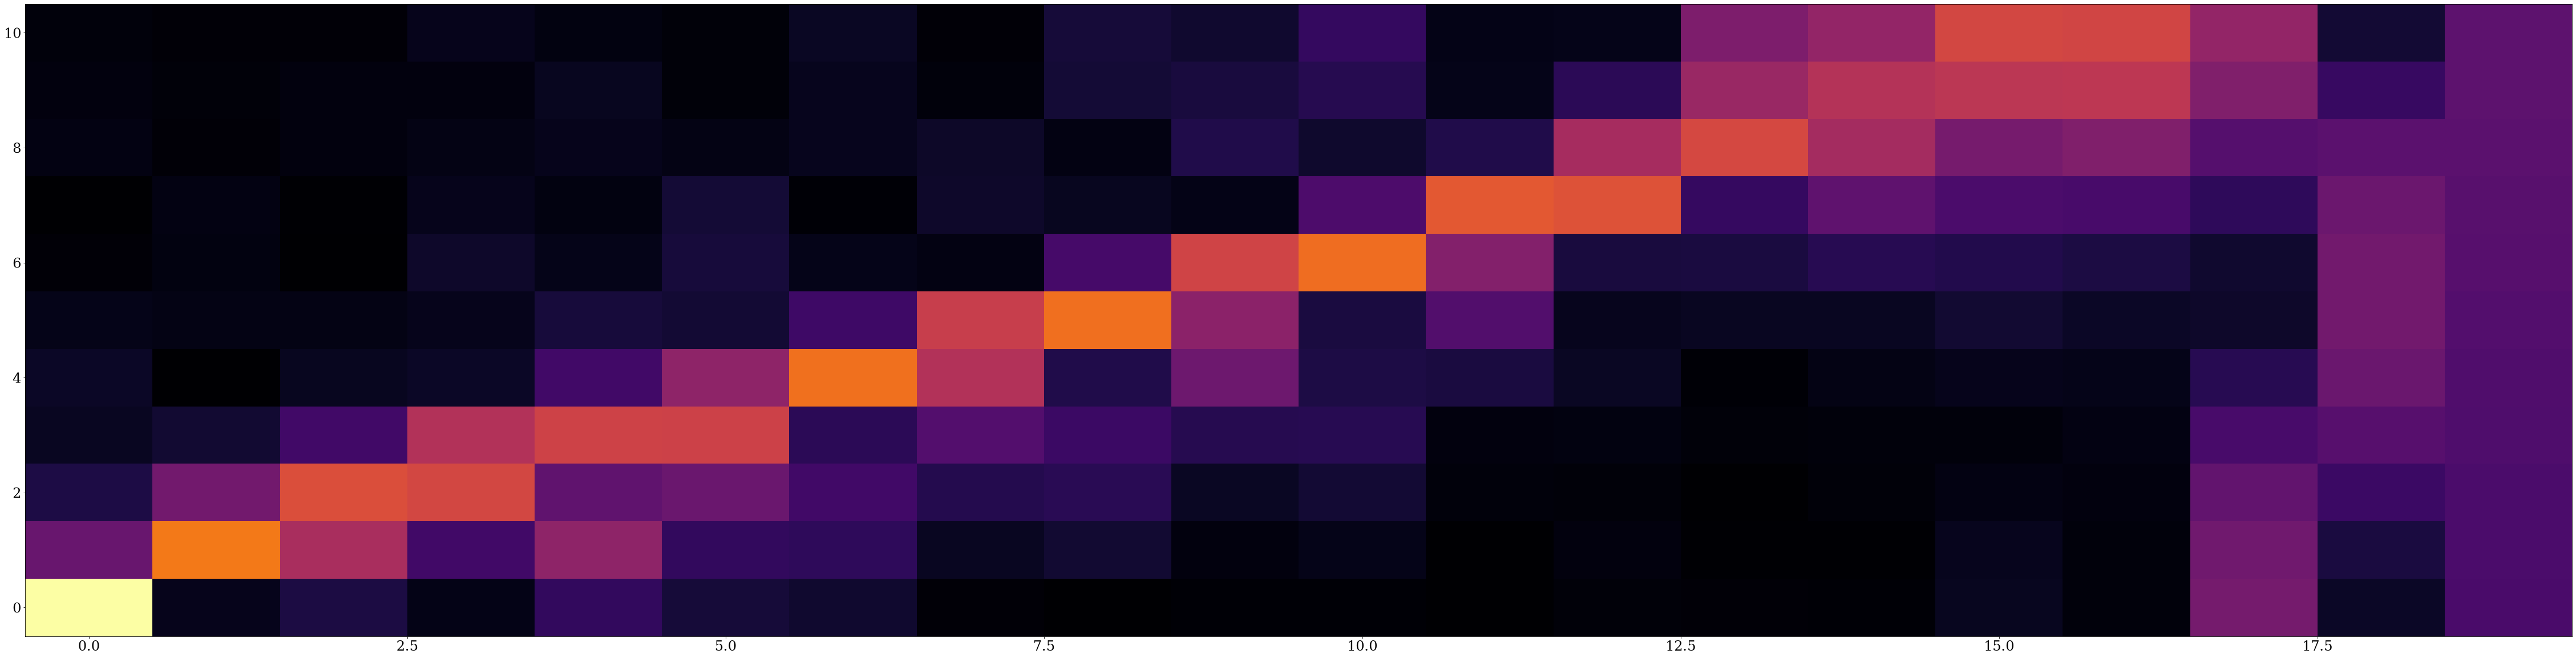

In [56]:
plt.figure(figsize=(20*4, 5*4))
modal_spectrum = np.abs(np.fft.rfft(np.real(vects[:,order[:50]]), axis=0))
plt.imshow(modal_spectrum, aspect='auto')

In [57]:
vcts = np.real(vects[:,order])
if np.mean(vcts[:,0]) < 0:
    vects_adj = vcts*np.ones(nwavels).at[0].mul(-1)
    print("yes")
else:
    vects_adj=vcts
numpy.save(f"../data/iterative_spectrum_basis_{filtname}.npy", vects_adj)

yes
